# Moje první analýza

Tento notebook procvičuje práci s Jupyter Notebooky, numpy a matplotlib.

## Vzorec

Pythagorova věta:

$$ c = \sqrt{a^2 + b^2} $$

Inline použití: pro $a = 3$ a $b = 4$ vyjde $c = 5$.

## Obrázek

![Logo Pythonu](https://www.python.org/static/community_logos/python-logo-master-v3-TM.png)

In [39]:
# automatický výstup poslední hodnoty v buňce
a = 3
b = 4
c = (a**2 + b**2) ** 0.5
c

5.0

In [40]:
!uv add cowsay

Resolved 112 packages in 82ms
Audited 108 packages in 65ms


In [41]:
# použití nainstalované knihovny
import cowsay
cowsay.cow("Ahoj z Jupyteru!")

  ________________
| Ahoj z Jupyteru! |
                \
                 \
                   ^__^
                   (oo)\_______
                   (__)\       )\/\
                       ||----w |
                       ||     ||


In [52]:
import numpy as np

# 1. Načtení dat
data = np.load("pacienti.npy")
print(data[0:5,:])
# 2. Průměr a std každého ukazatele
print("Průměr po sloupcích (SYS, DIA, TF ): ", data.mean(axis=0))
print("Směrodatnou odchylka po sloupcich:   ", data.std(axis=0))
# 3. Pacienti s hypertenzí (systolický ≥ 140)
hyper=data[data[:,0]>= 140]
print(f'Pocet pacientov s hypertenziou: {len(hyper)}')
print(f"Priemerny systolicky tlak {np.mean(data[:,0]):.1f}mmHg")

# 4. Pulzní tlak jako nový sloupec


# 5. Pacient s nejvyšší tepovou frekvencí


[[129.6  78.2  93. ]
 [109.4  73.2  72. ]
 [136.3  92.2  61. ]
 [139.1  78.5  89. ]
 [ 95.7  75.7  80. ]]
Průměr po sloupcích (SYS, DIA, TF ):  [124.51   81.105  77.   ]
Směrodatnou odchylka po sloupcich:    [12.72807527  7.73869983 11.28273017]
Pocet pacientov s hypertenziou: 1
Priemerny systolicky tlak 124.5mmHg


Načteno 7 klidových a 6 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


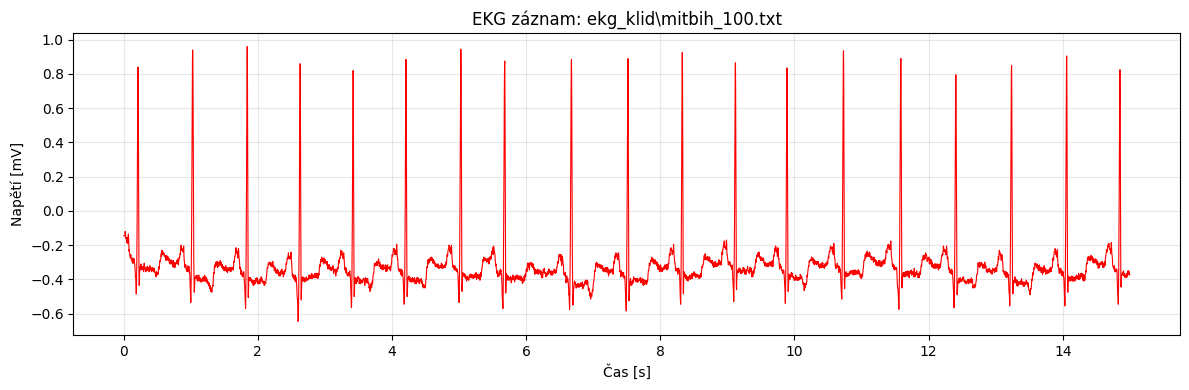

In [57]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1) Získej seznamy souborů
files_klid  = sorted(glob.glob("ekg_klid/*.txt"))
files_zatez = sorted(glob.glob("ekg_zatez/*.txt"))


# 2) Načti první klidový záznam a rozbal t a ekg
data0 = np.loadtxt(files_klid[0], skiprows=1)
t   = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(files_klid)} klidových a {len(files_zatez)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1]-t[0]):.0f} Hz")


plt.figure(figsize=(12, 4))
plt.plot(t, ekg, color='red', linewidth=0.8)
plt.title(f"EKG záznam: {files_klid[0]}")
plt.xlabel("Čas [s]")


plt.ylabel("Napětí [mV]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

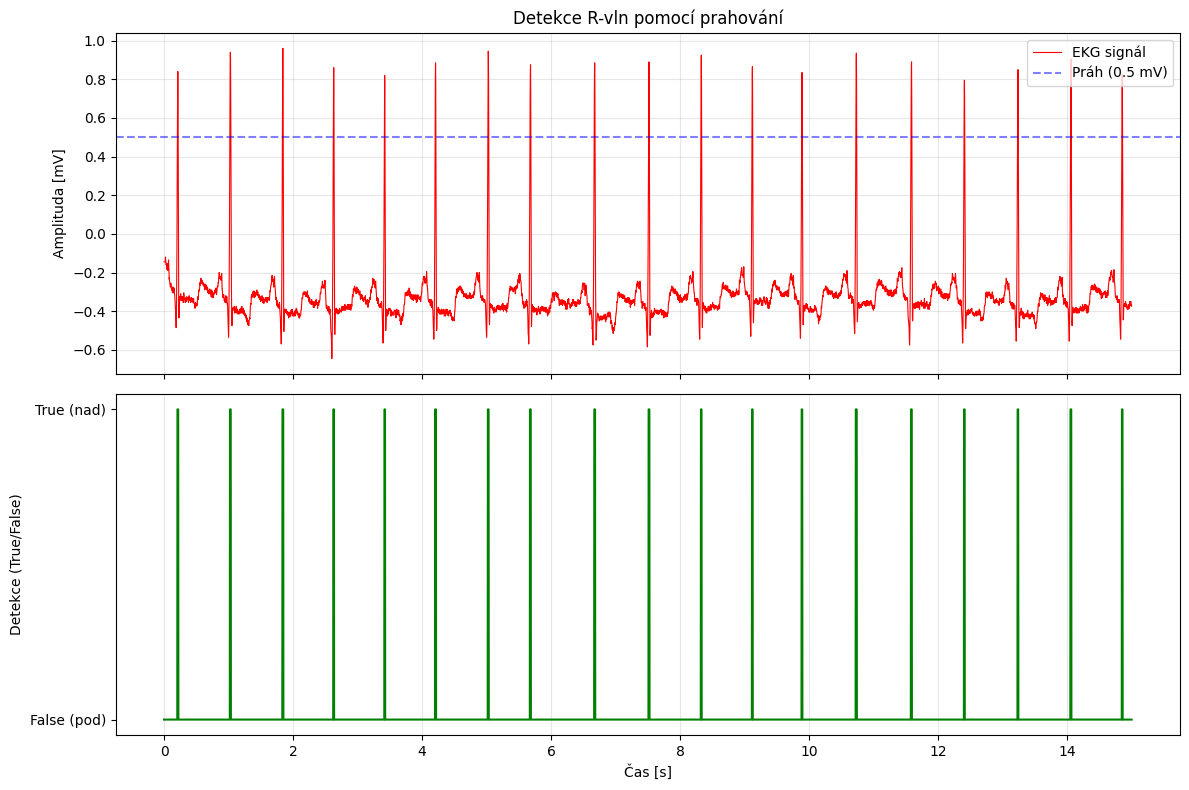

In [58]:
PRAH=0.5
nad_prahem = ekg > PRAH

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.plot(t, ekg, color='red', linewidth=0.8, label='EKG signál')
ax1.axhline(y=PRAH, color='blue', linestyle='--', alpha=0.5, label=f'Práh ({PRAH} mV)')
ax1.set_ylabel("Amplituda [mV]")
ax1.set_title("Detekce R-vln pomocí prahování")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)


ax2.plot(t, nad_prahem, color='green', linewidth=1.5)
ax2.set_ylabel("Detekce (True/False)")
ax2.set_xlabel("Čas [s]")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['False (pod)', 'True (nad)'])
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 1) Detekce R-vrcholů: sestupná hrana (np.diff == -1) v binárním signálu nad_prahem
vrcholy_idx = ...

print(f"Nalezeno vrcholů: {len(vrcholy_idx)}")

# 2) Vykresli signál + značky (scatter) na pozicích t[vrcholy_idx], ekg[vrcholy_idx]